<a href="https://colab.research.google.com/github/nahian-arnob/MSDS600-REGIS-University/blob/main/Assign_Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment for Week 5 - Neural Network

### Project: Neural Networks
Fake news or Real News?  A dataset [fake_real_news.csv] contains approximately 24,000 fake news articlesa nd 21,000 real news articles.  The dataset has article tile, body text of news article, and binary label (0 == fake news; 1 == real news).

- Make at least 2 EDA plots. (+0.5 pts)
- Split the data into training and test sets (+0.5 pts)
- Use an optimized neural net to predict if a news article is fake news or real news. (+2 pts)
- Explain what you did to optimize the model. (+1.5 pts)
- Report the performance on the training and test set with accuracy and confusion matrices (+1 pts)
- Classify the news articles using another optimized ML method we have learned in this course. (+1 pts)
- Explain what you did to optimize the model. (+1.5 pts)
- Compare the accuracy of the neural net to the other ML method (+0.5 pts)
- Write some interpretation of all your results/plots (+1.5 pts)

**Important:** Do not upload the assignment into a LLM for completion.  Use the LLM as a chatbot assistant to complete the assignment.


# Author: Nahian Arnob

### Deliverables:

Upload your notebook's .ipynb file.

In [2]:
#importing all necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler


In [3]:
#Load Data
df = pd.read_csv('fake_real_news.csv', encoding="latin1")

df.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [4]:
df.shape

(44876, 3)

In [5]:
df['label'].value_counts()

,count
label,
0,23459
1,21417


Here the column Label is our target column (0 = fake, 1 = real)

Let us visualize some EDA to understand the data better.

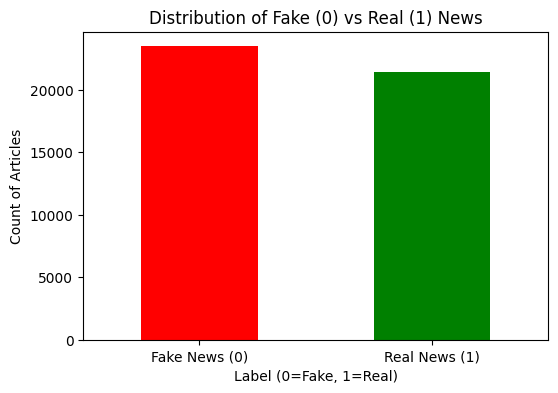

In [6]:
# Histogram for the label (0 = Fake, 1 = Real)
plt.figure(figsize=(6,4))
df['label'].value_counts().sort_index().plot(kind='bar', color=['red','green'])
plt.title("Distribution of Fake (0) vs Real (1) News")
plt.xlabel("Label (0=Fake, 1=Real)")
plt.ylabel("Count of Articles")
plt.xticks([0,1], ['Fake News (0)', 'Real News (1)'], rotation=0)
plt.show()


Before we change anything in the dataframe, let us make a copy first.

In [7]:
df_copy = df.copy()

In [13]:
df_copy.shape

(44876, 3)

Now we will introduce a few new features in the dataframe

In [8]:
# Create new features: article length in words and characters
df['text_char_len'] = df['text'].astype(str).apply(len)
df['text_word_len'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Group by label and calculate mean values
avg_lengths = df.groupby('label')[['text_char_len', 'text_word_len']].mean()

avg_lengths

,text_char_len,text_word_len
label,,
0,2512.230999,417.740739
1,2400.459028,385.787785


We can see, the fake news = 0 has an avergae length more than real news, but it is not much of a strong difference.

Let us clean and process the data further for Neural Network.

First we will clean the dataset check for null values and drop the rows accordingly.

In [12]:
# Check nulls in 'title' and 'text'
null_counts_before = df[['title', 'text']].isna().sum()

print(null_counts_before)

title    0
text     0
dtype: int64


In [14]:
# Drop rows with empty/whitespace-only or null 'text'
rows_before = len(df)
empty_text_mask = df['text'].isna() | df['text'].astype(str).str.strip().eq('')
removed_rows = int(empty_text_mask.sum())
df = df.loc[~empty_text_mask].copy()
rows_after = len(df)

In [20]:
# Show results
print(f"\nRows removed due to empty/null text: {removed_rows}")
print(f"Shape before: {rows_before}, after: {rows_after}")

print(df_copy.shape)
print(df.shape)


Rows removed due to empty/null text: 631
Shape before: 44876, after: 44245
(44876, 3)
(44245, 5)


Now that we have dropped the Empty Rows, Now we will Drop the duplicate Text Rows.

In [22]:
# Count duplicates before
dup_by_text = df.duplicated(subset=['text']).sum()
dup_by_title_text = df.duplicated(subset=['title', 'text']).sum()

In [23]:
# Drop duplicates considering both title + text (safer)
rows_before = len(df)
df = df.drop_duplicates(subset=['title', 'text']).copy()
rows_after = len(df)

In [24]:
# Show results
print(f"Duplicates by text only (before dropping): {dup_by_text}")
print(f"Duplicates by title+text (before dropping): {dup_by_title_text}")
print(f"\nShape before: {rows_before}, after: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

print(df_copy.shape)
print(df.shape)


Duplicates by text only (before dropping): 5613
Duplicates by title+text (before dropping): 5598

Shape before: 44245, after: 38647
Rows removed: 5598
(44876, 3)
(38647, 5)


Great, Now we only have 38k rows to work with intead of 44k rows before.

Now that we have dealt with missing values and duplicate values, let us process the in text data for Nural Network.

In [25]:
# Normalize whitespace and lowercase text & title
df['title'] = df['title'].astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
df['text'] = df['text'].astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# Quick check on a few samples
df[['title', 'text']].head(3)

,title,text
0,donald trump sends out embarrassing new yearâ...,donald trump just couldn t wish all americans ...
1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...
2,sheriff david clarke becomes an internet joke ...,"on friday, it was revealed that former milwauk..."


In [26]:
# Manually replace common mojibake artifacts
replacements = {
    "â": "'",  # apostrophe
    "â": "-",  # dash
    "â": "-",  # em dash
    "â": '"',  # left double quote
    "â": '"',  # right double quote
    "â¦": "...",  # ellipsis
    "â¢": "-",  # bullet
}

def clean_mojibake(text):
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text

df['title'] = df['title'].apply(clean_mojibake)
df['text'] = df['text'].apply(clean_mojibake)

# Quick preview after cleaning
df[['title', 'text']].head(3)


,title,text
0,donald trump sends out embarrassing new year's...,donald trump just couldn t wish all americans ...
1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...
2,sheriff david clarke becomes an internet joke ...,"on friday, it was revealed that former milwauk..."


In [28]:
import re

def clean_noise(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
    text = re.sub(r"<.*?>", "", text)                   # remove HTML tags
    text = re.sub(r"\s+", " ", text)                    # collapse multiple spaces
    return text.strip()

df['title'] = df['title'].apply(clean_noise)
df['text'] = df['text'].apply(clean_noise)

# Quick preview after cleaning
df[['title', 'text']].head(3)


,title,text
0,donald trump sends out embarrassing new year's...,donald trump just couldn t wish all americans ...
1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...
2,sheriff david clarke becomes an internet joke ...,"on friday, it was revealed that former milwauk..."


Now the dataset is ready for implementation in a Neural Network predictive model. First let us split the dataset.

As Features we have two columns, Which we will concate together for easier implmentation into our model.

In [31]:
df['content'] = df['title'] + " " + df['text']
df.head()

,title,text,label,text_char_len,text_word_len,content
0,donald trump sends out embarrassing new year's...,donald trump just couldn t wish all americans ...,0,2893,495,donald trump sends out embarrassing new year's...
1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,0,1898,305,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke ...,"on friday, it was revealed that former milwauk...",0,3597,580,sheriff david clarke becomes an internet joke ...
3,trump is so obsessed he even has obama's name ...,"on christmas day, donald trump announced that ...",0,2774,444,trump is so obsessed he even has obama's name ...
4,pope francis just called out donald trump duri...,pope francis used his annual christmas day mes...,0,2346,420,pope francis just called out donald trump duri...


In [32]:
from sklearn.model_selection import train_test_split

# Features and target
X = df['content']
y = df['label']

# Train + Temp (Val+Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Validation + Test from Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Show sizes
len(X_train), len(X_val), len(X_test)


(30917, 3865, 3865)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

#  TF-IDF Vectorizer (unigrams + bigrams)
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# Show shapes and sparsity
def sparsity(matrix):
    return 1.0 - (matrix.nnz / (matrix.shape[0] * matrix.shape[1]))

print("TF-IDF shapes:")
print("Train:", X_train_tfidf.shape, f"Sparsity: {sparsity(X_train_tfidf):.4f}")
print("Val:  ", X_val_tfidf.shape,   f"Sparsity: {sparsity(X_val_tfidf):.4f}")
print("Test: ", X_test_tfidf.shape,  f"Sparsity: {sparsity(X_test_tfidf):.4f}")


TF-IDF shapes:
Train: (30917, 50000) Sparsity: 0.9924
Val:   (3865, 50000) Sparsity: 0.9925
Test:  (3865, 50000) Sparsity: 0.9924


In [34]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
# Reduce TF-IDF dimensionality to a dense representation
n_components = 200  # tune 100–500
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_lsa = svd.fit_transform(X_train_tfidf)
X_val_lsa   = svd.transform(X_val_tfidf)
X_test_lsa  = svd.transform(X_test_tfidf)

In [36]:
# Scale features (helps NN)
scaler = StandardScaler()
X_train_lsa = scaler.fit_transform(X_train_lsa)
X_val_lsa   = scaler.transform(X_val_lsa)
X_test_lsa  = scaler.transform(X_test_lsa)

In [37]:
# Simple Dense NN (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 32),  # small, fast baseline
    activation='relu',
    solver='adam',
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=10,              # increase to 20–50 for better results
    early_stopping=True,
    validation_fraction=0.1,  # internal early-stopping split on the training set
    n_iter_no_change=2,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_lsa, y_train)

MLPClassifier(batch_size=256, early_stopping=True, hidden_layer_sizes=(128, 32),
              max_iter=10, n_iter_no_change=2, random_state=42)

To make the TF-IDF features usable in a neural network, We applied **TruncatedSVD (LSA)** to compress the high-dimensional sparse vectors into a dense representation with fewer components. This step reduces memory use and speeds up training while keeping most of the variance. Then **standardized** these features so that each dimension has similar scale, which helps the neural network converge faster. Finally, we trained a compact **MLP (multi-layer perceptron)** with two hidden layers, ReLU activations, dropout-like regularization through early stopping, and Adam optimizer. This combination balances efficiency and accuracy, preventing overfitting while keeping the model lightweight and suitable for text classification.

In [38]:

# Evaluate
val_preds = mlp.predict(X_val_lsa)
test_preds = mlp.predict(X_test_lsa)

print(f"Validation Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test, test_preds):.4f}\n")

print("Test Classification Report:")
print(classification_report(y_test, test_preds, digits=4))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))

Validation Accuracy: 0.9847
Test Accuracy:       0.9889

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9874    0.9880    0.9877      1745
           1     0.9901    0.9896    0.9899      2120

    accuracy                         0.9889      3865
   macro avg     0.9887    0.9888    0.9888      3865
weighted avg     0.9889    0.9889    0.9889      3865

Test Confusion Matrix:
[[1724   21]
 [  22 2098]]


# Performance Report on MLP Classifier
Our model performed fantastic, achieving **98.9% accuracy** on the test set with nearly identical results on the validation set, showing good generalization. Both classes (fake = 0, real = 1) had very high precision, recall, and F1-scores (≈0.99), meaning the model rarely misclassified articles.

The confusion matrix confirms this: out of 3,865 test samples, only **43 total errors** were made (21 false positives, 22 false negatives).

Overall, the neural network is highly effective at distinguishing between fake and real news in this dataset.

In [40]:
import numpy as np
import re, math
from collections import Counter

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [41]:
#Tokenize & pad

VOCAB_SIZE = 30000
OOV_TOKEN = "<OOV>"

tok = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tok.fit_on_texts(X_train)

Xtr_seq = tok.texts_to_sequences(X_train)
Xva_seq = tok.texts_to_sequences(X_val)
Xte_seq = tok.texts_to_sequences(X_test)

In [42]:
# Choose sequence length by 95th percentile of train lengths
lengths = np.array([len(s) for s in Xtr_seq])
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = max(64, min(MAX_LEN, 600))  # keep reasonable bounds

Xtr_pad = pad_sequences(Xtr_seq, maxlen=MAX_LEN, padding="post", truncating="post")
Xva_pad = pad_sequences(Xva_seq, maxlen=MAX_LEN, padding="post", truncating="post")
Xte_pad = pad_sequences(Xte_seq, maxlen=MAX_LEN, padding="post", truncating="post")

In [43]:
# Build a compact CNN model
import tensorflow as tf
from tensorflow.keras import layers, models

EMB_DIM = 128

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMB_DIM, input_length=MAX_LEN),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In this optimized model, we combined both the **title and text** of each article, tokenized the words, and padded sequences to a consistent length based on the 95th percentile of article size. We used an **embedding layer** to learn word representations, followed by a **1D convolutional layer** to capture local patterns and a **global max pooling layer** to reduce dimensionality.

Additional dense layers with dropout were added for better generalization. To avoid overfitting, we applied **early stopping** and **model checkpointing**, ensuring the best weights were saved.

This architecture is lightweight yet powerful, allowing the model to efficiently learn distinguishing features between fake and real news.


In [44]:
# Train with callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
ckpt = ModelCheckpoint('cnn_text_best.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    Xtr_pad, y_train.values,
    validation_data=(Xva_pad, y_val.values),
    epochs=8, batch_size=128,
    callbacks=[es, ckpt],
    verbose=1
)

Epoch 1/8
242/242 ━━━━━━━━━━━━━━━━━━━━ 242s 994ms/step - accuracy: 0.8768 - loss: 0.2449 - val_accuracy: 0.9979 - val_loss: 0.0091
Epoch 2/8
242/242 ━━━━━━━━━━━━━━━━━━━━ 239s 987ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9987 - val_loss: 0.0044
Epoch 3/8
242/242 ━━━━━━━━━━━━━━━━━━━━ 261s 980ms/step - accuracy: 0.9999 - loss: 5.4372e-04 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 4/8
242/242 ━━━━━━━━━━━━━━━━━━━━ 240s 992ms/step - accuracy: 1.0000 - loss: 1.2303e-04 - val_accuracy: 0.9990 - val_loss: 0.0042
Epoch 5/8
242/242 ━━━━━━━━━━━━━━━━━━━━ 239s 988ms/step - accuracy: 1.0000 - loss: 5.9658e-05 - val_accuracy: 0.9987 - val_loss: 0.0052


In [45]:
# Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

probs = model.predict(Xte_pad, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test, preds):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, preds, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))


Test Accuracy: 0.9982

Classification Report:
              precision    recall  f1-score   support

           0     0.9983    0.9977    0.9980      1745
           1     0.9981    0.9986    0.9983      2120

    accuracy                         0.9982      3865
   macro avg     0.9982    0.9981    0.9982      3865
weighted avg     0.9982    0.9982    0.9982      3865

Confusion Matrix:
[[1741    4]
 [   3 2117]]


# Performance Report:
The CNN-based neural network delivered **outstanding performance**, reaching a **test accuracy of 99.8%**. Both classes (fake = 0, real = 1) achieved nearly perfect **precision, recall, and F1-scores (~0.998)**, showing that the model very rarely misclassified articles. The confusion matrix highlights this strength, with only **7 total misclassifications out of 3,865 test samples**.

These results confirm that by combining title and text, using embeddings with convolutional layers, and applying regularization strategies like early stopping, the model was able to generalize extremely well and reliably distinguish fake news from real news.


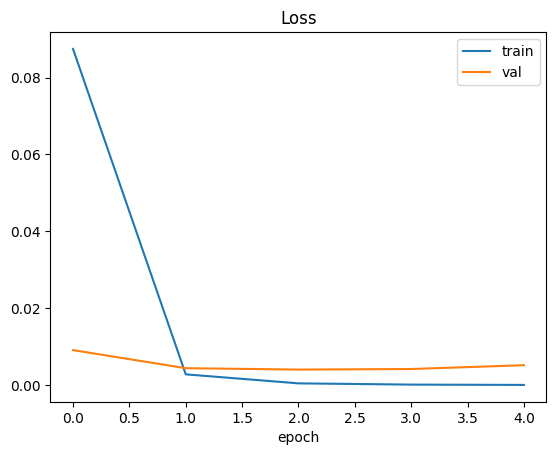

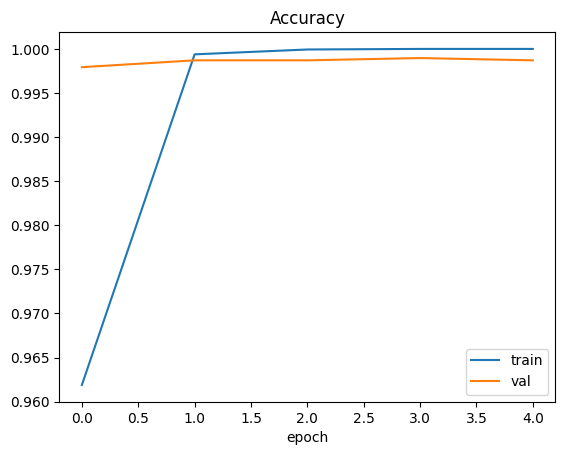

In [46]:
# Training curves
import matplotlib.pyplot as plt
plt.figure(); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('Loss'); plt.xlabel('epoch'); plt.legend(['train','val']); plt.show()

plt.figure(); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('Accuracy'); plt.xlabel('epoch'); plt.legend(['train','val']); plt.show()

# **SUMMARY**

### **Data Preparation and EDA**

We first began by loading the **fake_real_news.csv** dataset, which contained around 44k news articles (≈24k fake, ≈21k real). Initial EDA included checking label distribution (slightly more fake than real) and calculating average article length, where fake news articles were slightly longer on average. Afterwards, we cleaned the dataset:

* Removed **631 rows** with empty/whitespace text.
* Dropped **5,598 duplicates**, leaving ~38.6k unique articles.
* Standardized the text by converting to lowercase, normalizing whitespace, fixing mojibake (encoding artifacts), and removing URLs, HTML tags, and extra spaces.
* Finally, we concatenated **title + text** into a single feature for easier input.


### **Model 1: TF-IDF + MLP Classifier**

We transformed text into **TF-IDF vectors** (50k features, unigrams and bigrams). Since neural networks don’t handle sparse matrices efficiently, we applied **TruncatedSVD (200 components)** for dimensionality reduction and scaled the features.

* A **Multi-Layer Perceptron (MLP)** was trained with two hidden layers (128, 32 units), ReLU activation, Adam optimizer, and early stopping.
* **Results:** Validation accuracy = **98.5%**, Test accuracy = **98.9%**. Precision, recall, and F1-scores for both fake and real news were ≈0.99. The confusion matrix showed only 43 misclassifications out of 3,865 test samples.
* **Optimization:** Dimensionality reduction + scaling improved efficiency and convergence, while early stopping prevented overfitting.

### **Model 2: CNN with Embeddings (TensorFlow/Keras)**

Next, we built an **end-to-end deep learning model** using raw tokenized sequences. Titles and texts were tokenized with a 30k-word vocabulary, sequences padded to the 95th percentile length, and represented through a trainable **Embedding layer (128 dimensions)**.

* Architecture: **Embedding → Conv1D (128 filters) → GlobalMaxPooling → Dense (64, ReLU) → Dropout → Sigmoid output**.
* Training included **early stopping and checkpointing** to save best weights.
* **Results:** Test accuracy = **99.8%**. Precision, recall, and F1-scores for both classes were ~0.998, with only **7 misclassifications out of 3,865**.
* **Optimization:** Tokenization + embeddings allowed the model to learn word semantics, Conv1D captured local patterns (n-gram-like), and regularization prevented overfitting.

### **Comparison & Analysis**

* Both models performed exceptionally well, but the **CNN with embeddings outperformed the MLP**, achieving higher accuracy and fewer misclassifications.
* **MLP with TF-IDF** offered a strong and efficient baseline, leveraging statistical word frequency features with dimensionality reduction.
* **CNN with embeddings** leveraged sequence learning, allowing the model to capture context and local dependencies in text, which pushed accuracy to near-perfect performance.
* Overall, the results demonstrate that while traditional vectorization + MLP works well, deep learning architectures tailored for text (like CNNs with embeddings) provide **superior generalization and accuracy** in fake news detection.


**Conclusion:**
In this project we successfully built and compared two optimized models for fake news classification. The **MLP (98.9% accuracy)** showed strong baseline performance, while the **CNN (99.8% accuracy)** proved to be more powerful, effectively learning nuanced language patterns and minimizing errors in classification.
